In [135]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [13]:
df= pd.read_excel(r"D:\Documents\Maloshree\2026\Global food prices\wfp_market_food_prices.xlsx")

In [14]:
df.head(3)

,adm0_id,adm0_name,adm1_id,adm1_name,mkt_id,mkt_name,cm_id,cm_name,cur_id,cur_name,pt_id,pt_name,um_id,um_name,mp_month,mp_year,mp_price,mp_commoditysource
0,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,1,2014,50.0,WFP
1,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,2,2014,50.0,WFP
2,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,3,2014,50.0,WFP


In [15]:
df.shape

(743914, 18)

In [5]:
df.dtypes

adm0_id                 int64
adm0_name                 str
adm1_id                 int64
adm1_name                 str
mkt_id                  int64
mkt_name                  str
cm_id                   int64
cm_name                   str
cur_id                  int64
cur_name                  str
pt_id                   int64
pt_name                   str
um_id                   int64
um_name                   str
mp_month                int64
mp_year                 int64
mp_price              float64
mp_commoditysource        str
dtype: object

### column details 
1. adm0_id: country id
2. adm0_name: country name
3. adm1_id: locality id
4. adm1_name: locality name
5. mkt_id: market id
6. mkt_name: market name
7. cm_id: commodity purchase id
8. cm_name: commodity purchased
9. cur_id: currency id
10. cur_name: name of currency
11. pt_id: market type id
12. pt_name: market type (Retail/Wholesale/Producer/Farm Gate)
13. um_id: measurement id
14. um_name: unit of goods measurement
15. mp_month: month recorded
16. mpyear: year recorded
17. mpprice: price paid
18. mp_commoditysource: Source supplying price information

In [6]:
df.isnull().sum()

adm0_id                   0
adm0_name                 0
adm1_id                   0
adm1_name             13949
mkt_id                    0
mkt_name                  0
cm_id                     0
cm_name                   0
cur_id                    0
cur_name                  0
pt_id                     0
pt_name                   0
um_id                     0
um_name                   0
mp_month                  0
mp_year                   0
mp_price                  0
mp_commoditysource        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# drop missing values
df = df[df['adm1_name'].notna()]

In [9]:
df.isnull().sum()

adm0_id               0
adm0_name             0
adm1_id               0
adm1_name             0
mkt_id                0
mkt_name              0
cm_id                 0
cm_name               0
cur_id                0
cur_name              0
pt_id                 0
pt_name               0
um_id                 0
um_name               0
mp_month              0
mp_year               0
mp_price              0
mp_commoditysource    0
dtype: int64

In [10]:
df.describe()

,adm0_id,adm1_id,mkt_id,cm_id,cur_id,pt_id,um_id,mp_month,mp_year,mp_price
count,729965.000000,729965.000000,729965.000000,729965.000000,729965.000000,729965.000000,729965.000000,729965.000000,729965.000000,7.299650e+05
mean,860.524409,18005.919580,888.111248,160.927520,57.259937,14.930860,10.500401,6.378896,2012.507628,4.234829e+03
std,6379.306857,82078.325302,540.712015,117.931311,23.135316,0.277758,13.126298,3.434346,3.675369,5.600542e+04
min,1.000000,272.000000,80.000000,50.000000,22.000000,14.000000,5.000000,1.000000,1992.000000,0.000000e+00
25%,115.000000,1577.000000,380.000000,67.000000,29.000000,15.000000,5.000000,3.000000,2011.000000,3.100000e+01
50%,170.000000,2208.000000,911.000000,110.000000,63.000000,15.000000,5.000000,6.000000,2013.000000,1.778750e+02
75%,205.000000,21969.000000,1134.000000,233.000000,77.000000,15.000000,5.000000,9.000000,2015.000000,5.062000e+02
max,70001.000000,900022.000000,2094.000000,490.000000,95.000000,18.000000,100.000000,12.000000,2017.000000,5.833333e+06


In [11]:
#fields to exclude
col = ['adm0_name', 'mkt_name', 'cm_name', 'cur_name', 'pt_name', 'um_name', 'mp_month', 'mp_year', 'mp_price']

In [16]:
df2 = df[col]

In [17]:
df['adm0_name'].value_counts().to_frame()

,count
adm0_name,
Rwanda,115037
India,68308
Niger,36195
Mali,32702
Democratic Republic of the Congo,29997
...,...
Cape Verde,276
Panama,174
Azerbaijan,125


In [18]:
df['mkt_name'].value_counts().to_frame()

,count
mkt_name,
National Average,11904
Khujand,4056
Dushanbe,4055
Gharm,4044
Kurgan-Tyube,4043
...,...
Douekire,6
Ouani,4
Taboye,3


In [19]:
u = list(df['cm_name'].unique())
u.sort()
u

['Apples',
 'Apples (red)',
 'Avocados',
 'Bananas',
 'Bananas (medium size)',
 'Beans',
 'Beans (black)',
 'Beans (butter)',
 'Beans (catarino)',
 'Beans (dry)',
 'Beans (fava, dry)',
 'Beans (green, fresh)',
 'Beans (haricot)',
 'Beans (kidney red)',
 'Beans (kidney white)',
 'Beans (kidney)',
 'Beans (magnum)',
 'Beans (mung)',
 'Beans (niebe)',
 'Beans (niebe, white)',
 'Beans (red)',
 'Beans (red, fresh)',
 'Beans (silk red)',
 'Beans (string)',
 'Beans (sugar) ',
 'Beans (sugar-red)',
 'Beans (white)',
 'Beans(mash)',
 'Beetroots',
 'Blackberry',
 'Bread',
 'Bread (bakery)',
 'Bread (brown)',
 'Bread (common)',
 'Bread (first grade flour)',
 'Bread (high grade flour)',
 'Bread (khoboz)',
 'Bread (pita)',
 'Bread (rye)',
 'Bread (shop)',
 'Bread (wheat)',
 'Broccoli',
 'Buckwheat grits',
 'Bulgur',
 'Butter',
 'Cabbage',
 'Carrots',
 'Cashew',
 'Cassava',
 'Cassava (chikwangue)',
 'Cassava (cossette)',
 'Cassava (dry)',
 'Cassava (fresh)',
 'Cassava flour',
 'Cassava leaves',
 'Ca

In [64]:
df[df['cm_name'].str.contains('Exchange rate')]

,adm0_id,adm0_name,adm1_id,adm1_name,mkt_id,mkt_name,cm_id,cm_name,cur_id,cur_name,pt_id,pt_name,um_id,um_name,mp_month,mp_year,mp_price,mp_commoditysource
500,1,Afghanistan,272,Badakhshan,266,Fayzabad,305,Exchange rate,87,AFN,15,Retail,56,USD/LCU,2,2014,57.550,WFP
501,1,Afghanistan,272,Badakhshan,266,Fayzabad,305,Exchange rate,87,AFN,15,Retail,56,USD/LCU,7,2014,56.600,WFP
502,1,Afghanistan,272,Badakhshan,266,Fayzabad,305,Exchange rate,87,AFN,15,Retail,56,USD/LCU,8,2014,56.625,WFP
503,1,Afghanistan,272,Badakhshan,266,Fayzabad,305,Exchange rate,87,AFN,15,Retail,56,USD/LCU,9,2014,57.000,WFP
504,1,Afghanistan,272,Badakhshan,266,Fayzabad,305,Exchange rate,87,AFN,15,Retail,56,USD/LCU,10,2014,57.375,WFP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
741968,70001,South Sudan,2748,Central Equatoria,1388,Konyo Konyo,473,Exchange rate (unofficial),83,SSP,15,Retail,56,USD/LCU,3,2017,115.000,WFP
741969,70001,South Sudan,2748,Central Equatoria,1388,Konyo Konyo,473,Exchange rate (unofficial),83,SSP,15,Retail,56,USD/LCU,4,2017,155.900,WFP
741970,70001,South Sudan,2748,Central Equatoria,1388,Konyo Konyo,473,Exchange rate (unofficial),83,SSP,15,Retail,56,USD/LCU,5,2017,147.600,WFP
742903,70001,South Sudan,2746,Lakes,1390,Rumbek,473,Exchange rate (unofficial),83,SSP,15,Retail,56,USD/LCU,2,2017,111.150,WFP


In [65]:
pd.crosstab(df["adm0_name"],
            df["cur_name"])
          

cur_name,AFN,AMD,BDT,BIF,BOB,CDF,COP,CVE,DJF,DZD,...,Somaliland Shilling,TJS,TZS,UAH,UGX,USD,XAF,XOF,YER,ZMW
adm0_name,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4676,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Algeria,0,0,0,0,0,0,0,0,0,1784,...,0,0,0,0,0,0,0,0,0,0
Armenia,0,5778,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bangladesh,0,0,3035,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Benin,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3452,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ukraine,0,0,0,0,0,0,0,0,0,0,...,0,0,0,24766,0,0,0,0,0,0
United Republic of Tanzania,0,0,0,0,0,0,0,0,0,0,...,0,0,7457,0,0,0,0,0,0,0
Yemen,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9105,0


In [66]:
(df[df['um_name']=='USD/LCU']).groupby('adm0_name')['cur_name'].first().to_frame()

,cur_name
adm0_name,
Afghanistan,AFN
Democratic Republic of the Congo,CDF
Ethiopia,ETB
Liberia,LRD
South Sudan,SSP
Tajikistan,TJS


In [20]:
df[df['cm_name'].str.contains('Bread')].groupby('cm_name')['cm_name'].first().values

<ArrowStringArray>
[                    'Bread',            'Bread (bakery)',
             'Bread (brown)',            'Bread (common)',
 'Bread (first grade flour)',  'Bread (high grade flour)',
            'Bread (khoboz)',              'Bread (pita)',
               'Bread (rye)',              'Bread (shop)',
             'Bread (wheat)']
Length: 11, dtype: str

In [21]:
df = df[df['cm_name'].str.contains('Bread') | 
        df['cm_name'].str.contains('Milk') | 
        df['cm_name'].str.contains('Meat') | 
        df['cm_name'].str.contains('Fish') | 
        df['cm_name'].str.contains('Rice') |
        df['cm_name'].str.contains('Water') |
        df['cm_name'].str.contains('Exchange rate')]
df

,adm0_id,adm0_name,adm1_id,adm1_name,mkt_id,mkt_name,cm_id,cm_name,cur_id,cur_name,pt_id,pt_name,um_id,um_name,mp_month,mp_year,mp_price,mp_commoditysource
0,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,1,2014,50.00,WFP
1,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,2,2014,50.00,WFP
2,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,3,2014,50.00,WFP
3,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,4,2014,50.00,WFP
4,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,5,2014,50.00,WFP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
741968,70001,South Sudan,2748,Central Equatoria,1388,Konyo Konyo,473,Exchange rate (unofficial),83,SSP,15,Retail,56,USD/LCU,3,2017,115.00,WFP
741969,70001,South Sudan,2748,Central Equatoria,1388,Konyo Konyo,473,Exchange rate (unofficial),83,SSP,15,Retail,56,USD/LCU,4,2017,155.90,WFP
741970,70001,South Sudan,2748,Central Equatoria,1388,Konyo Konyo,473,Exchange rate (unofficial),83,SSP,15,Retail,56,USD/LCU,5,2017,147.60,WFP
742903,70001,South Sudan,2746,Lakes,1390,Rumbek,473,Exchange rate (unofficial),83,SSP,15,Retail,56,USD/LCU,2,2017,111.15,WFP


In [22]:
u = list(df['cm_name'].unique())
u.sort()
u

['Bread',
 'Bread (bakery)',
 'Bread (brown)',
 'Bread (common)',
 'Bread (first grade flour)',
 'Bread (high grade flour)',
 'Bread (khoboz)',
 'Bread (pita)',
 'Bread (rye)',
 'Bread (shop)',
 'Bread (wheat)',
 'Exchange rate',
 'Exchange rate (unofficial)',
 'Fish',
 'Fish (appolo)',
 'Fish (bonga)',
 'Fish (canned)',
 'Fish (catfish)',
 'Fish (dry)',
 'Fish (fresh)',
 'Fish (frozen)',
 'Fish (red snapper)',
 'Fish (salted)',
 'Fish (sardine, canned)',
 'Fish (smoked)',
 'Fish (snake head)',
 'Fish (tilapia)',
 'Fish (tilapia, farmed)',
 'Fish (tuna, canned)',
 'Meat (beef)',
 'Meat (beef, canned)',
 'Meat (beef, chops with bones)',
 'Meat (beef, first quality)',
 'Meat (beef, minced)',
 'Meat (beef, second quality)',
 'Meat (beef, without bones)',
 'Meat (buffalo, first quality)',
 'Meat (buffalo, second quality)',
 'Meat (camel)',
 'Meat (chicken)',
 'Meat (chicken, broiler)',
 'Meat (chicken, frozen)',
 'Meat (chicken, imported)',
 'Meat (chicken, whole)',
 'Meat (goat)',
 'Meat 

In [23]:
df.loc[:, 'cm_name'] = df['cm_name'].apply(lambda x : str(x) if str(x).find(' (') == -1 else str(x)[:str(x).find(' (')] )
df

,adm0_id,adm0_name,adm1_id,adm1_name,mkt_id,mkt_name,cm_id,cm_name,cur_id,cur_name,pt_id,pt_name,um_id,um_name,mp_month,mp_year,mp_price,mp_commoditysource
0,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,1,2014,50.00,WFP
1,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,2,2014,50.00,WFP
2,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,3,2014,50.00,WFP
3,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,4,2014,50.00,WFP
4,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,5,2014,50.00,WFP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
741968,70001,South Sudan,2748,Central Equatoria,1388,Konyo Konyo,473,Exchange rate,83,SSP,15,Retail,56,USD/LCU,3,2017,115.00,WFP
741969,70001,South Sudan,2748,Central Equatoria,1388,Konyo Konyo,473,Exchange rate,83,SSP,15,Retail,56,USD/LCU,4,2017,155.90,WFP
741970,70001,South Sudan,2748,Central Equatoria,1388,Konyo Konyo,473,Exchange rate,83,SSP,15,Retail,56,USD/LCU,5,2017,147.60,WFP
742903,70001,South Sudan,2746,Lakes,1390,Rumbek,473,Exchange rate,83,SSP,15,Retail,56,USD/LCU,2,2017,111.15,WFP


In [25]:
u = list(df['cm_name'].unique())
u.sort()
u

['Bread', 'Exchange rate', 'Fish', 'Meat', 'Milk', 'Rice', 'Water']

In [26]:
df['pt_name'].unique()

<ArrowStringArray>
['Retail', 'Wholesale', 'Producer', 'Farm Gate']
Length: 4, dtype: str

In [27]:
pd.crosstab(df["um_name"],
            df["cm_name"],
            )

cm_name,Bread,Exchange rate,Fish,Meat,Milk,Rice,Water
um_name,,,,,,,
1.5 KG,2760,0,0,0,0,0,0
1.8 KG,0,0,0,0,177,0,0
100 KG,0,0,0,0,0,3076,0
125 G,0,0,502,0,0,0,0
150 G,1344,0,0,0,0,0,0
185 G,0,0,502,0,0,0,0
200 G,0,0,0,864,0,0,0
25 KG,0,0,0,0,0,383,0
380 G,0,0,0,0,68,0,0


In [28]:
d= {'KG': 1,
 'Unit': 1,
 'Pound': 0.45,
 '400 G': 0.4,
 '150 G': 0.15,
 '5 pcs': 1,
 '500 G': 0.5,
 '700 G': 0.7,
 '800 G': 0.8,
 '1.1 KG': 1.1,
 'Libra': 0.45,
 '900 G': 0.9,
 '100 KG': 100,
 '46 KG': 46,
 'Cuartilla': 2.88,
 '90 KG': 90,
 '120 KG': 120,
 '50 KG': 50,
 'MT': 1000,
 '45 KG': 45,
 '84 KG': 84,
 '100 Pounds': 45,
 'Marmite': 1,
 '5 KG': 5,
 '10 KG': 10,
 '1.4 KG': 1.4,
 '25 KG': 25,
 '2 KG': 2,
 'Loaf' : 1,
 '50 Pounds': 22.5,
 '380 G': 0.38,
 '500 ML': 0.5,
 '385 G': 0.385,
 '0.8 KG': 0.8,
 '200 ML': 0.2,
 '20 G': 0.02,
 '1.8 KG': 1.8,
 '125 G': 0.125,
 '20 KG': 20,
 '170 G': 0.17,
 '185 G': 0.185,
 '200 G': 0.2,
 '1.5 KG': 1.5,
 '1.2 KG': 1.2,
 'Bundle': 46,
 '160 G': 0.16,
 'Cubic meter': 1,
 '1.5 L': 1.5,
 'L': 1,
 'USD/LCU': 1}

In [30]:
df['um_koef'] = df['um_name'].map(d)
df['mp_price_un'] = df['mp_price'] / df['um_koef']
df

,adm0_id,adm0_name,adm1_id,adm1_name,mkt_id,mkt_name,cm_id,cm_name,cur_id,cur_name,pt_id,pt_name,um_id,um_name,mp_month,mp_year,mp_price,mp_commoditysource,um_koef,mp_price_un
0,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,1,2014,50.00,WFP,1.0,50.00
1,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,2,2014,50.00,WFP,1.0,50.00
2,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,3,2014,50.00,WFP,1.0,50.00
3,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,4,2014,50.00,WFP,1.0,50.00
4,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,5,2014,50.00,WFP,1.0,50.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
741968,70001,South Sudan,2748,Central Equatoria,1388,Konyo Konyo,473,Exchange rate,83,SSP,15,Retail,56,USD/LCU,3,2017,115.00,WFP,1.0,115.00
741969,70001,South Sudan,2748,Central Equatoria,1388,Konyo Konyo,473,Exchange rate,83,SSP,15,Retail,56,USD/LCU,4,2017,155.90,WFP,1.0,155.90
741970,70001,South Sudan,2748,Central Equatoria,1388,Konyo Konyo,473,Exchange rate,83,SSP,15,Retail,56,USD/LCU,5,2017,147.60,WFP,1.0,147.60
742903,70001,South Sudan,2746,Lakes,1390,Rumbek,473,Exchange rate,83,SSP,15,Retail,56,USD/LCU,2,2017,111.15,WFP,1.0,111.15


In [40]:
df_res = pd.pivot_table(df, 
                        values= 'mp_price', index= ['adm0_name', 'mp_year', 'mp_month', 'mkt_name'], 
                        columns=['cm_name'], aggfunc='mean', margins=False
                       )
df_res

cm_name                                  Bread  Exchange rate  Fish  Meat  \
adm0_name   mp_year mp_month mkt_name                                       
Afghanistan 2007    1        Fayzabad      NaN            NaN   NaN   NaN   
                             Gardez        NaN            NaN   NaN   NaN   
                             Hirat         NaN            NaN   NaN   NaN   
                             Jalalabad     NaN            NaN   NaN   NaN   
                             Kabul         NaN            NaN   NaN   NaN   
...                                        ...            ...   ...   ...   
Zambia      2017    6        Senanga       NaN            NaN   NaN   NaN   
                             Sesheke       NaN            NaN   NaN   NaN   
                             Shang'ombo    NaN            NaN   NaN   NaN   
                             Solwezi       NaN            NaN   NaN   NaN   
                             Zambezi       NaN            NaN   NaN   NaN   

cm_name                                  Milk     Rice  Water  
adm0_name   mp_year mp_month mkt_name                          
Afghanistan 2007    1        Fayzabad     NaN  24.0000    NaN  
                             Gardez       NaN  23.0000    NaN  
                             Hirat        NaN  26.1667    NaN  
                             Jalalabad    NaN  15.0000    NaN  
                             Kabul        NaN  17.7000    NaN  
...                                       ...      ...    ...  
Zambia      2017    6        Senanga      NaN   9.5700    NaN  
                             Sesheke      NaN  19.0600    NaN  
                             Shang'ombo   NaN  19.0500    NaN  
                             Solwezi      NaN  18.7500    NaN  
                             Zambezi      NaN  12.6500    NaN  

[82562 rows x 7 columns]

In [41]:
df_res.columns

Index(['Bread', 'Exchange rate', 'Fish', 'Meat', 'Milk', 'Rice', 'Water'], dtype='str', name='cm_name')

### Statistical Analysis

In [42]:
df_stat = df_res.reset_index()
df_stat

cm_name,adm0_name,mp_year,mp_month,mkt_name,Bread,Exchange rate,Fish,Meat,Milk,Rice,Water
0,Afghanistan,2007,1,Fayzabad,NaN,NaN,NaN,NaN,NaN,24.0000,NaN
1,Afghanistan,2007,1,Gardez,NaN,NaN,NaN,NaN,NaN,23.0000,NaN
2,Afghanistan,2007,1,Hirat,NaN,NaN,NaN,NaN,NaN,26.1667,NaN
3,Afghanistan,2007,1,Jalalabad,NaN,NaN,NaN,NaN,NaN,15.0000,NaN
4,Afghanistan,2007,1,Kabul,NaN,NaN,NaN,NaN,NaN,17.7000,NaN
...,...,...,...,...,...,...,...,...,...,...,...
82557,Zambia,2017,6,Senanga,NaN,NaN,NaN,NaN,NaN,9.5700,NaN
82558,Zambia,2017,6,Sesheke,NaN,NaN,NaN,NaN,NaN,19.0600,NaN
82559,Zambia,2017,6,Shang'ombo,NaN,NaN,NaN,NaN,NaN,19.0500,NaN
82560,Zambia,2017,6,Solwezi,NaN,NaN,NaN,NaN,NaN,18.7500,NaN


In [52]:
df_stat.dtypes


cm_name
adm0_name            str
mp_year            int64
mp_month           int64
mkt_name             str
Bread            float64
Exchange rate    float64
Fish             float64
Meat             float64
Milk             float64
Rice             float64
Water            float64
dtype: object

In [43]:
df_stat["adm0_name"].value_counts().to_frame()

,count
adm0_name,
India,7382
Mali,7084
Niger,5629
Senegal,5244
Rwanda,3751
...,...
Burkina Faso,57
South Sudan,57
Turkey,42


In [44]:
df_stat["adm0_name"].value_counts(normalize=True).to_frame()

,proportion
adm0_name,
India,0.089412
Mali,0.085802
Niger,0.068179
Senegal,0.063516
Rwanda,0.045433
...,...
Burkina Faso,0.000690
South Sudan,0.000690
Turkey,0.000509


In [45]:
df_stat["adm0_name"].unique()

<ArrowStringArray>
[                     'Afghanistan',                          'Algeria',
                          'Armenia',                       'Azerbaijan',
                       'Bangladesh',                            'Benin',
                           'Bhutan',                          'Bolivia',
                     'Burkina Faso',                          'Burundi',
                         'Cambodia',                         'Cameroon',
                       'Cape Verde',         'Central African Republic',
                             'Chad',                         'Colombia',
                            'Congo',                       'Costa Rica',
                    'Cote d'Ivoire', 'Democratic Republic of the Congo',
                         'Djibouti',                            'Egypt',
                      'El Salvador',                         'Ethiopia',
                           'Gambia',                            'Ghana',
                        'Guatema

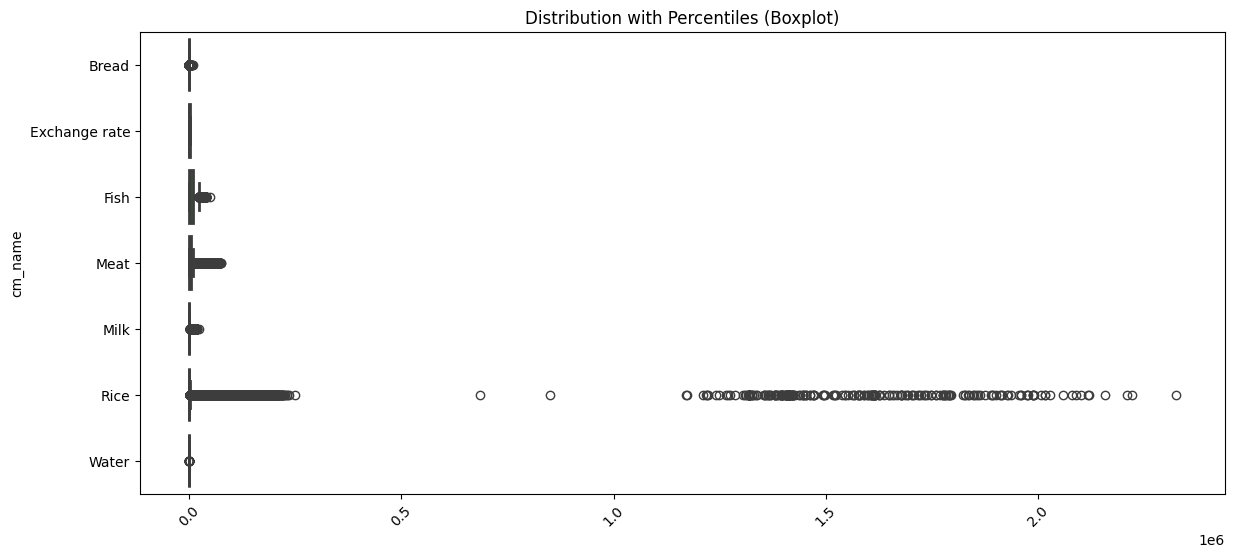

In [167]:
cols = ['Bread','Exchange rate','Fish', 'Meat','Milk','Rice','Water']

plt.figure(figsize=(14,6))

sns.boxplot(data=df_stat[cols], linewidth =2, orient = "h")

plt.xticks(rotation=45)
plt.title("Distribution with Percentiles (Boxplot)")
plt.show()

In [169]:
corrx =df.select_dtypes(include=np.number)
corrx.corr(method ='spearman')

,adm0_id,adm1_id,mkt_id,cm_id,cur_id,pt_id,um_id,mp_month,mp_year,mp_price,um_koef,mp_price_un
adm0_id,1.000000,0.713640,0.169011,-0.117088,0.255514,0.097716,-0.061250,0.003008,0.114366,-0.179291,0.157084,-0.187672
adm1_id,0.713640,1.000000,0.044598,-0.066043,0.159246,0.099545,-0.054168,0.000557,0.073861,-0.140600,0.092966,-0.140462
mkt_id,0.169011,0.044598,1.000000,0.227739,0.583261,0.137239,-0.039084,-0.005520,0.357836,0.180875,-0.004129,0.217144
cm_id,-0.117088,-0.066043,0.227739,1.000000,0.237536,0.155456,0.219806,-0.005052,0.187514,0.162262,-0.161042,0.219873
cur_id,0.255514,0.159246,0.583261,0.237536,1.000000,0.075614,0.087965,0.016803,0.282079,-0.102220,-0.033021,-0.073214
pt_id,0.097716,0.099545,0.137239,0.155456,0.075614,1.000000,-0.250808,-0.000443,0.053586,-0.193494,-0.472268,0.006565
um_id,-0.061250,-0.054168,-0.039084,0.219806,0.087965,-0.250808,1.000000,-0.006427,0.062306,-0.289344,-0.032392,-0.365309
mp_month,0.003008,0.000557,-0.005520,-0.005052,0.016803,-0.000443,-0.006427,1.000000,-0.116387,0.006163,0.000946,0.005807
mp_year,0.114366,0.073861,0.357836,0.187514,0.282079,0.053586,0.062306,-0.116387,1.000000,0.162041,0.066522,0.166880
mp_price,-0.179291,-0.140600,0.180875,0.162262,-0.102220,-0.193494,-0.289344,0.006163,0.162041,1.000000,0.272764,0.941593


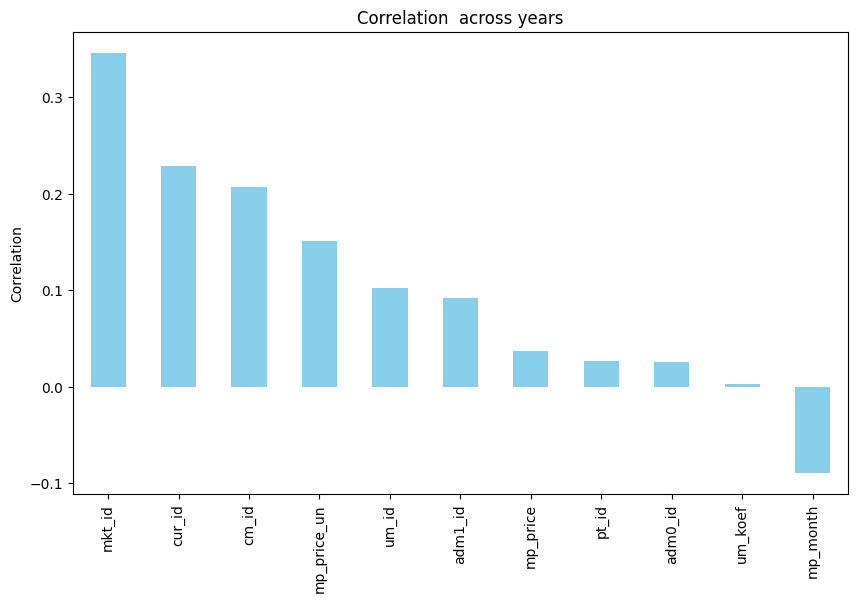

In [170]:
corrx =df.select_dtypes(include=np.number).corr()['mp_year'].sort_values(ascending= False)
#plot
plt.figure (figsize=(10,6))
corrx.drop('mp_year').plot(kind ='bar', color ='skyblue')
plt.title('Correlation  across years')
plt.ylabel('Correlation')
plt.show()

In [143]:
df_stat[df_stat['adm0_name']=='Mali'].describe()

cm_name,mp_year,mp_month,Bread,Exchange rate,Fish,Meat,Milk,Rice,Water
count,7084.000000,7084.000000,0.0,0.0,0.0,0.0,0.0,7084.000000,0.0
mean,2011.777527,6.308159,NaN,NaN,NaN,NaN,NaN,334.259872,NaN
std,3.311436,3.417784,NaN,NaN,NaN,NaN,NaN,53.885123,NaN
min,2003.000000,1.000000,NaN,NaN,NaN,NaN,NaN,146.100000,NaN
25%,2009.000000,3.000000,NaN,NaN,NaN,NaN,NaN,300.000000,NaN
50%,2011.000000,6.000000,NaN,NaN,NaN,NaN,NaN,341.500000,NaN
75%,2015.000000,9.000000,NaN,NaN,NaN,NaN,NaN,368.750000,NaN
max,2017.000000,12.000000,NaN,NaN,NaN,NaN,NaN,563.000000,NaN


In [47]:
df_stat[df_stat['adm0_name']=='India'].describe()

cm_name,mp_year,mp_month,Bread,Exchange rate,Fish,Meat,Milk,Rice,Water
count,7382.000000,7382.00000,0.0,0.0,0.0,0.0,3258.000000,7381.000000,0.0
mean,2008.848957,6.34977,NaN,NaN,NaN,NaN,37.655712,19.604978,NaN
std,6.659857,3.45166,NaN,NaN,NaN,NaN,7.235055,8.474114,NaN
min,1994.000000,1.00000,NaN,NaN,NaN,NaN,20.000000,5.000000,NaN
25%,2004.000000,3.00000,NaN,NaN,NaN,NaN,34.000000,11.750000,NaN
50%,2011.000000,6.00000,NaN,NaN,NaN,NaN,38.000000,19.900000,NaN
75%,2014.000000,9.00000,NaN,NaN,NaN,NaN,41.000000,26.000000,NaN
max,2017.000000,12.00000,NaN,NaN,NaN,NaN,65.000000,54.000000,NaN


In [48]:
df_stat[df_stat['adm0_name']=='Ukraine'].describe()

cm_name,mp_year,mp_month,Bread,Exchange rate,Fish,Meat,Milk,Rice,Water
count,1032.000000,1032.000000,1032.000000,0.0,0.0,1032.000000,1032.000000,1032.000000,0.0
mean,2015.360465,6.272287,9.028436,NaN,NaN,57.876872,11.521172,15.916545,NaN
std,1.011048,3.345087,2.322089,NaN,NaN,9.602861,2.883540,3.538416,NaN
min,2014.000000,1.000000,4.490000,NaN,NaN,34.902500,6.813300,8.003300,NaN
25%,2015.000000,3.000000,6.764987,NaN,NaN,50.715200,8.948325,14.810025,NaN
50%,2015.000000,6.000000,9.745000,NaN,NaN,59.937925,11.218350,16.343350,NaN
75%,2016.000000,9.000000,10.723725,NaN,NaN,64.124600,13.234150,17.599200,NaN
max,2017.000000,12.000000,13.736650,NaN,NaN,86.749175,18.723300,29.753300,NaN


In [50]:
df_stat[df_stat['adm0_name']=='Niger'].describe()

cm_name,mp_year,mp_month,Bread,Exchange rate,Fish,Meat,Milk,Rice,Water
count,5629.000000,5629.000000,0.0,0.0,0.0,0.0,0.0,5629.000000,0.0
mean,2012.572571,6.420323,NaN,NaN,NaN,NaN,NaN,468.013373,NaN
std,2.515538,3.359832,NaN,NaN,NaN,NaN,NaN,47.398483,NaN
min,2008.000000,1.000000,NaN,NaN,NaN,NaN,NaN,45.000000,NaN
25%,2010.000000,4.000000,NaN,NaN,NaN,NaN,NaN,448.000000,NaN
50%,2013.000000,6.000000,NaN,NaN,NaN,NaN,NaN,465.165200,NaN
75%,2015.000000,9.000000,NaN,NaN,NaN,NaN,NaN,500.000000,NaN
max,2017.000000,12.000000,NaN,NaN,NaN,NaN,NaN,717.094100,NaN


In [62]:
india = (
    df_stat[df_stat['adm0_name'] == 'India']
    .groupby('mp_year')[
        ['mp_month','Bread', 'Exchange rate', 'Fish', 'Meat', 'Milk', 'Rice', 'Water']
    ]
    .mean()
)

india

cm_name,mp_month,Bread,Exchange rate,Fish,Meat,Milk,Rice,Water
mp_year,,,,,,,,
1994,6.897260,NaN,NaN,NaN,NaN,NaN,7.820890,NaN
1995,6.578431,NaN,NaN,NaN,NaN,NaN,8.033333,NaN
1996,6.578199,NaN,NaN,NaN,NaN,NaN,9.046682,NaN
1997,6.454976,NaN,NaN,NaN,NaN,NaN,9.633649,NaN
1998,6.412621,NaN,NaN,NaN,NaN,NaN,10.124029,NaN
1999,6.409326,NaN,NaN,NaN,NaN,NaN,11.174870,NaN
2000,6.469388,NaN,NaN,NaN,NaN,NaN,10.953571,NaN
2001,2.884615,NaN,NaN,NaN,NaN,NaN,10.243590,NaN
2002,6.524038,NaN,NaN,NaN,NaN,NaN,10.490385,NaN


<Axes: xlabel='mp_year'>

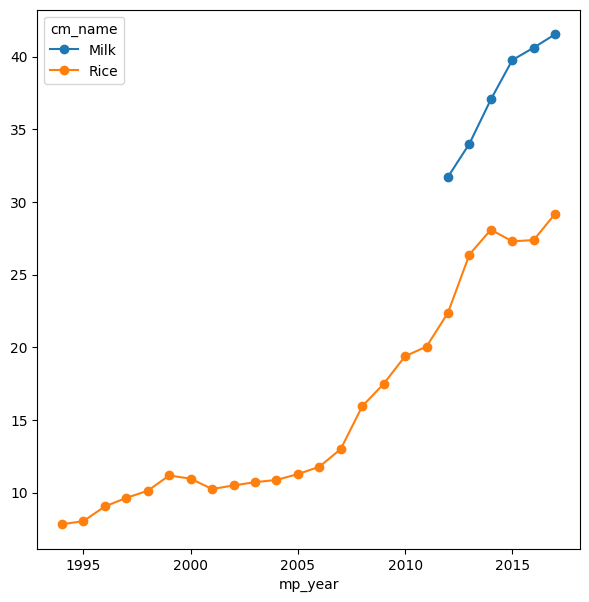

In [132]:
india[['Milk','Rice']].plot(figsize=(7,7), marker ='o')

In [64]:
mali = (
    df_stat[df_stat['adm0_name'] == 'Mali']
    .groupby('mp_year')[
        ['mp_month','Bread', 'Exchange rate', 'Fish', 'Meat', 'Milk', 'Rice', 'Water']
    ]
    .mean()
)

mali

cm_name,mp_month,Bread,Exchange rate,Fish,Meat,Milk,Rice,Water
mp_year,,,,,,,,
2003,6.500000,NaN,NaN,NaN,NaN,NaN,250.000000,NaN
2004,6.500000,NaN,NaN,NaN,NaN,NaN,259.360833,NaN
2005,6.500000,NaN,NaN,NaN,NaN,NaN,277.812500,NaN
2006,6.500000,NaN,NaN,NaN,NaN,NaN,279.958333,NaN
2007,6.538356,NaN,NaN,NaN,NaN,NaN,267.306995,NaN
2008,6.500000,NaN,NaN,NaN,NaN,NaN,333.884500,NaN
2009,6.470426,NaN,NaN,NaN,NaN,NaN,330.609922,NaN
2010,6.573257,NaN,NaN,NaN,NaN,NaN,315.310642,NaN
2011,5.729600,NaN,NaN,NaN,NaN,NaN,338.014037,NaN


<Axes: xlabel='mp_year'>

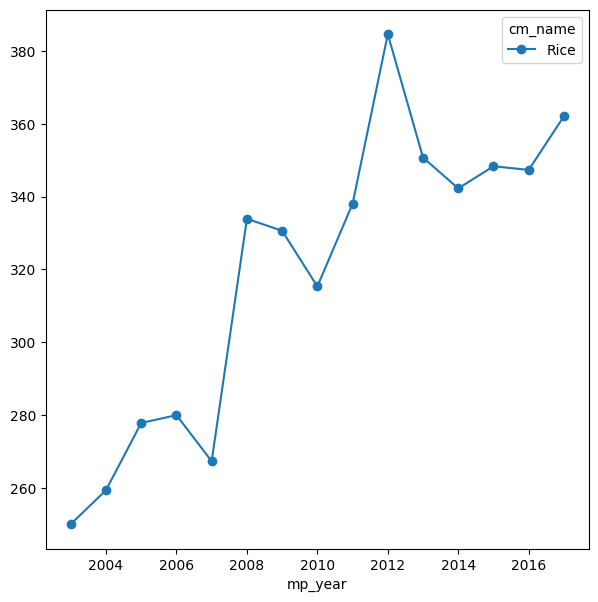

In [131]:
mali[['Rice']].plot(figsize=(7,7), marker ='o')

In [67]:
ukraine = (
    df_stat[df_stat['adm0_name'] == 'Ukraine']
    .groupby('mp_year')[
        ['mp_month','Bread', 'Exchange rate', 'Fish', 'Meat', 'Milk', 'Rice', 'Water']
    ]
    .mean()
)

ukraine

cm_name,mp_month,Bread,Exchange rate,Fish,Meat,Milk,Rice,Water
mp_year,,,,,,,,
2014,7.424603,5.624756,NaN,NaN,44.446600,8.249869,11.087064,NaN
2015,6.500000,9.287194,NaN,NaN,58.431265,10.353771,19.127234,NaN
2016,6.500000,10.243792,NaN,NaN,61.823505,12.895138,15.938645,NaN
2017,3.500000,11.578463,NaN,NaN,70.569877,16.392456,17.252438,NaN


<Axes: xlabel='mp_year'>

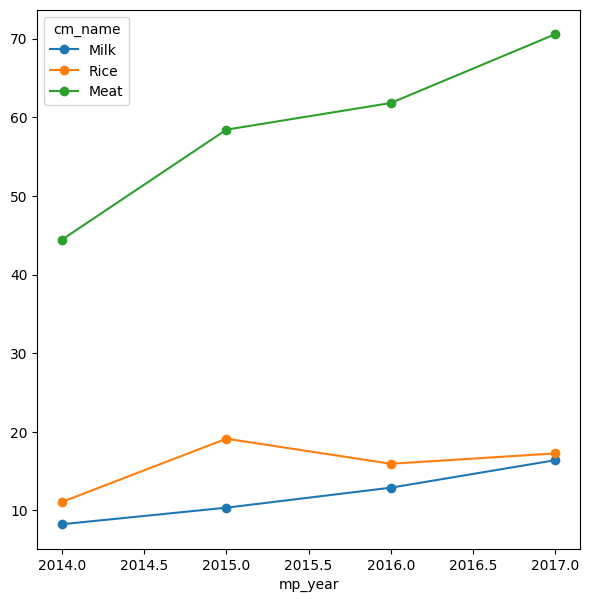

In [133]:
ukraine[['Milk','Rice','Meat']].plot(figsize=(7,7), marker ='o')

In [70]:
niger = (
    df_stat[df_stat['adm0_name'] == 'Niger']
    .groupby('mp_year')[
        ['mp_month','Bread', 'Exchange rate', 'Fish', 'Meat', 'Milk', 'Rice', 'Water']
    ]
    .mean()
)

niger

cm_name,mp_month,Bread,Exchange rate,Fish,Meat,Milk,Rice,Water
mp_year,,,,,,,,
2008,6.500000,NaN,NaN,NaN,NaN,NaN,435.993056,NaN
2009,6.703379,NaN,NaN,NaN,NaN,NaN,466.016956,NaN
2010,6.444295,NaN,NaN,NaN,NaN,NaN,439.022556,NaN
2011,6.792722,NaN,NaN,NaN,NaN,NaN,481.536605,NaN
2012,8.161554,NaN,NaN,NaN,NaN,NaN,483.985813,NaN
2013,6.882870,NaN,NaN,NaN,NaN,NaN,477.609758,NaN
2014,5.992690,NaN,NaN,NaN,NaN,NaN,474.681549,NaN
2015,6.011713,NaN,NaN,NaN,NaN,NaN,471.082475,NaN
2016,6.211921,NaN,NaN,NaN,NaN,NaN,465.842715,NaN


<Axes: xlabel='mp_year'>

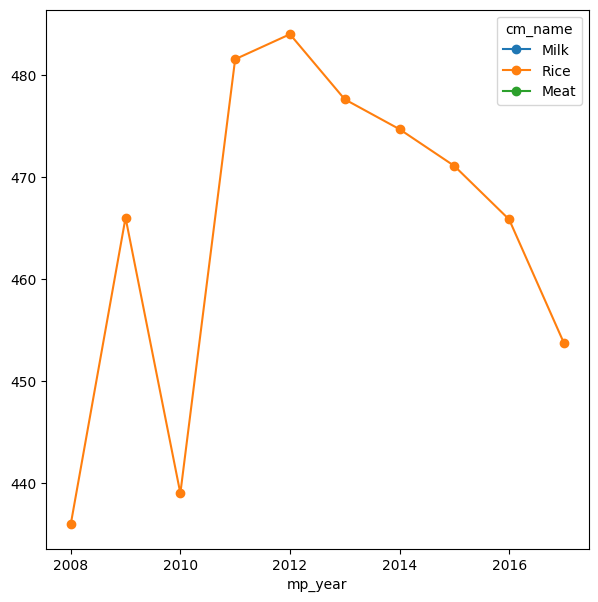

In [134]:
niger[['Milk','Rice','Meat']].plot(figsize=(7,7), marker ='o')

mkt_name
Port Blair      41.645424
Panaji          36.802955
Ernakulam       33.718590
T.Puram         33.100333
Jodhpur         31.038286
                  ...    
Guwahati        14.430239
Shillong        13.793571
Bhopal          13.777222
Bhubaneshwar    13.442528
Lucknow         13.136293
Name: Rice, Length: 61, dtype: float64


<Axes: xlabel='mkt_name'>

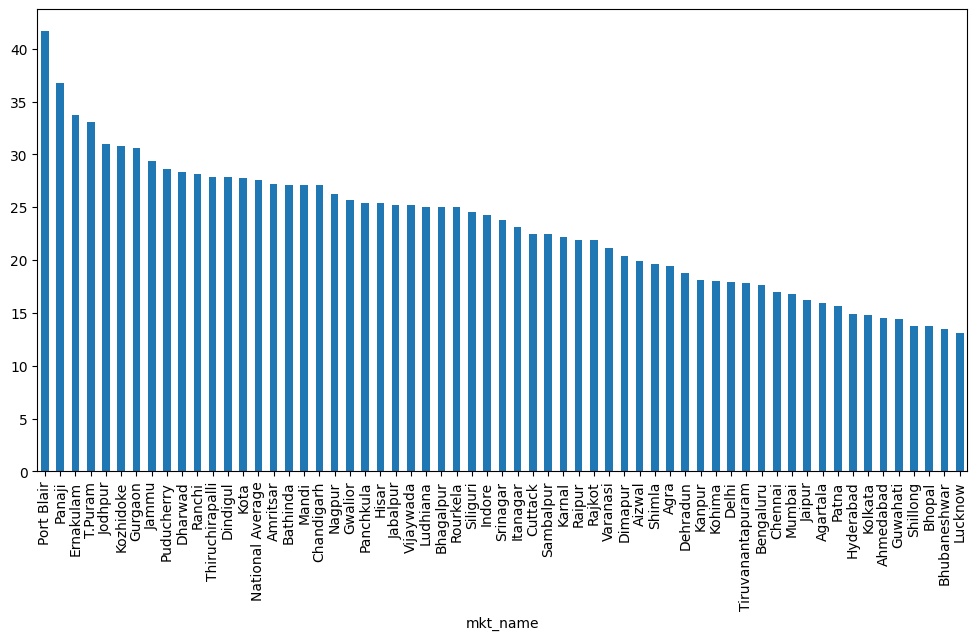

In [86]:
india1 = df_stat[df_stat['adm0_name']=='India'].groupby(['mkt_name'])['Rice'].mean().sort_values(ascending = False)
print(india1)
india1.plot.bar(figsize=(12, 6))

mkt_name
Anderamboukane    485.000000
Menaka            473.750000
Kayes Centre      430.909919
Boni              419.625000
Djebock           408.750000
                     ...    
San               273.671923
Sokolo            271.418208
Macina            258.805031
Tonka             227.047737
Dire              218.813384
Name: Rice, Length: 102, dtype: float64


<Axes: xlabel='mkt_name'>

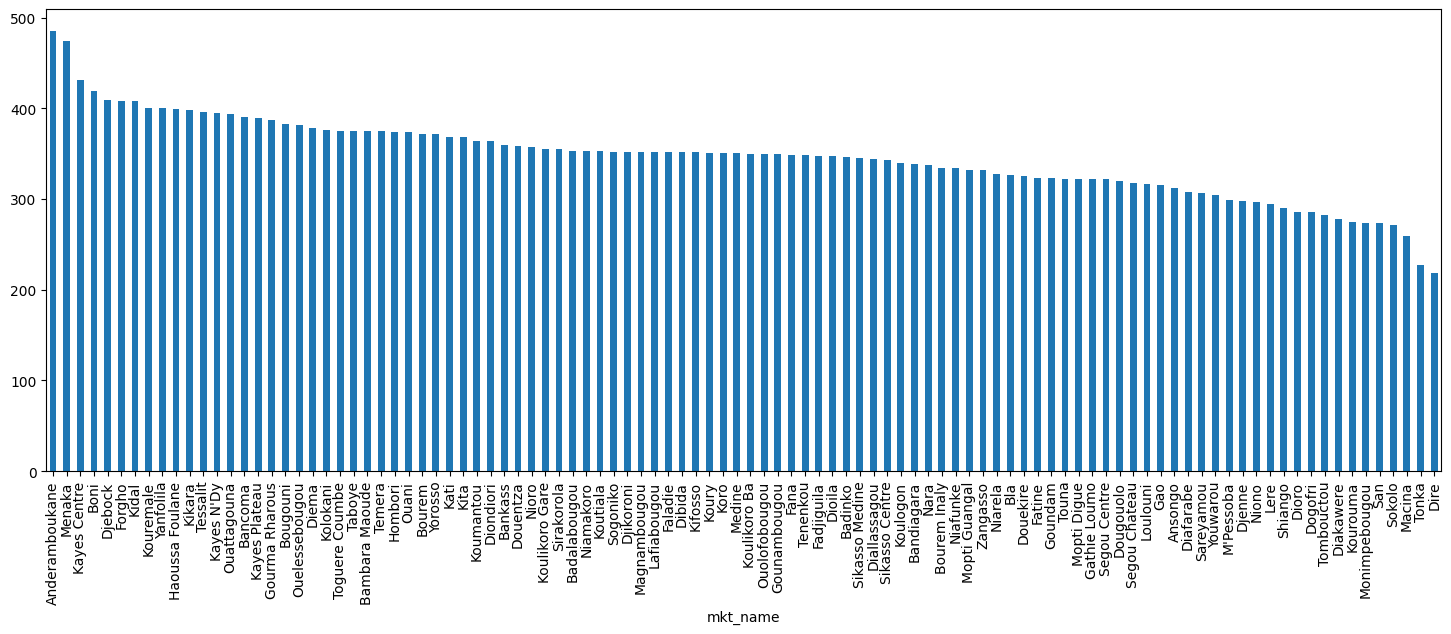

In [84]:
mali1 = df_stat[df_stat['adm0_name']=='Mali'].groupby(['mkt_name'])['Rice'].mean().sort_values(ascending = False)
print(mali1)
mali1.plot.bar(figsize=(18, 6))

mkt_name
Port Blair      41.645424
Panaji          36.802955
Ernakulam       33.718590
T.Puram         33.100333
Jodhpur         31.038286
                  ...    
Guwahati        14.430239
Shillong        13.793571
Bhopal          13.777222
Bhubaneshwar    13.442528
Lucknow         13.136293
Name: Rice, Length: 61, dtype: float64


<Axes: xlabel='mkt_name'>

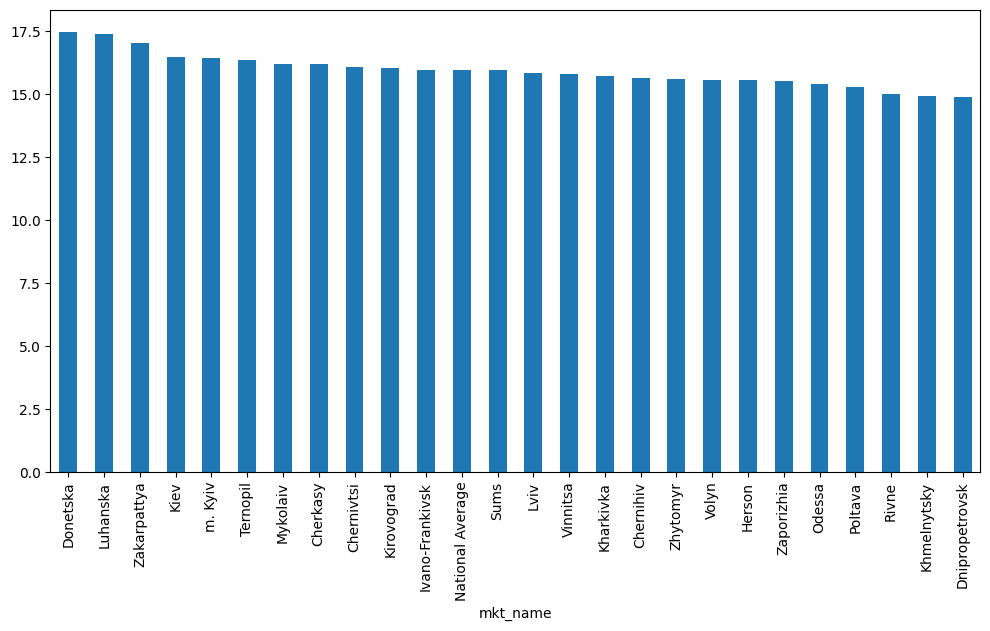

In [87]:
ukraine1 = df_stat[df_stat['adm0_name']=='Ukraine'].groupby(['mkt_name'])['Rice'].mean().sort_values(ascending = False)
print(india1)
ukraine1.plot.bar(figsize=(12, 6))

mkt_name
Chetimari            596.043467
Nguigmi              574.354507
Arlit                546.161048
Kazoe                524.524995
Goudoumaria          514.972087
                        ...    
Harobanda            414.353264
Gaya                 410.513685
Gotheye              408.399940
Tera                 405.437547
Tillaberi Commune    399.979741
Name: Rice, Length: 73, dtype: float64


<Axes: xlabel='mkt_name'>

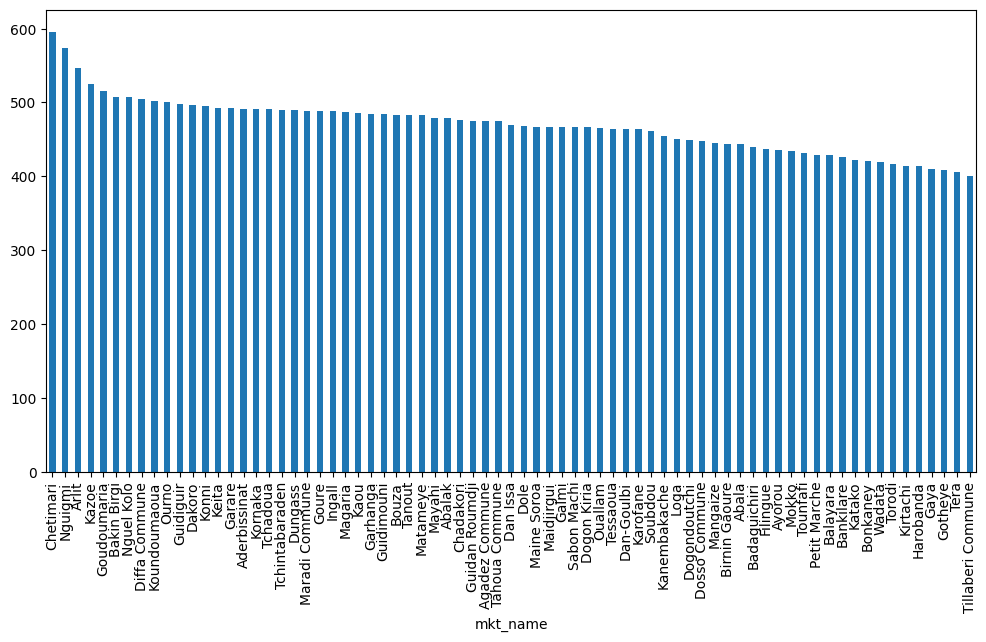

In [89]:
niger1 = df_stat[df_stat['adm0_name']=='Niger'].groupby(['mkt_name'])['Rice'].mean().sort_values(ascending = False)
print(niger1)
niger1.plot.bar(figsize=(12, 6))

mkt_name
Bengaluru       84.601064
Aizwal          84.519555
Chennai         78.880352
Bhubaneshwar    76.707950
Hyderabad       75.773810
dtype: float64


<Axes: xlabel='mp_year'>

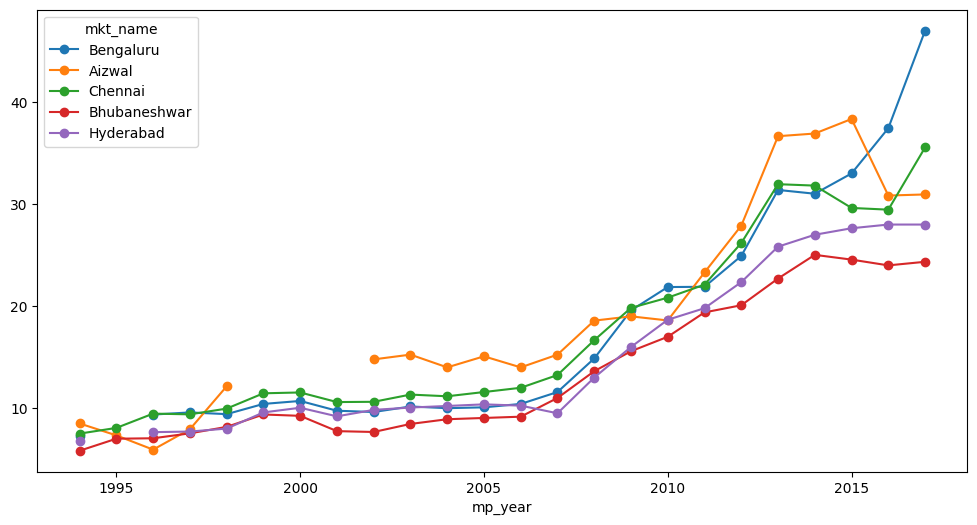

In [104]:
#market price changes over years in India
d = df_stat[df_stat['adm0_name'] == 'India']
d = d[['mkt_name', 'mp_year', 'Rice']]

pivot = pd.pivot_table(
    d,
    values='Rice',
    index='mp_year',
    columns='mkt_name',
    aggfunc='mean'
)

# Overall %change for each market
change = ((pivot.max() - pivot.min())/pivot.max()) *100

# Top 5 markets
top5 = change.nlargest(5)

print(top5)

# Plot only those markets over time
pivot[top5.index].plot(figsize=(12, 6),  marker='o')

In [105]:
# for countries where the national currency is USD
usd_countries = list((df[(df['cur_name']=='USD')])['adm0_name'].unique())
usd_countries

['Costa Rica', 'El Salvador', 'Honduras', 'Panama', 'Timor-Leste']

In [106]:
df_stat.loc[:, 'Exchange rate'] = df_stat.apply(lambda x : 1 if x['adm0_name'] in usd_countries else x['Exchange rate'], axis=1 )

In [107]:
df_stat_multy = df_stat[df_stat['Exchange rate'].notna()]
df_stat_multy

cm_name,adm0_name,mp_year,mp_month,mkt_name,Bread,Exchange rate,Fish,Meat,Milk,Rice,Water
699,Afghanistan,2014,2,Fayzabad,50.0,57.550,NaN,NaN,NaN,50.00000,NaN
700,Afghanistan,2014,2,Hirat,29.4,57.650,NaN,NaN,NaN,25.40000,NaN
701,Afghanistan,2014,2,Jalalabad,33.3,57.700,NaN,NaN,NaN,48.37500,NaN
702,Afghanistan,2014,2,Kabul,38.5,57.675,NaN,NaN,NaN,50.00000,NaN
703,Afghanistan,2014,2,Kandahar,37.0,58.250,NaN,NaN,NaN,24.37500,NaN
...,...,...,...,...,...,...,...,...,...,...,...
75680,Timor-Leste,2016,9,Dili,NaN,1.000,NaN,2.800,NaN,1.50625,NaN
75681,Timor-Leste,2016,10,Dili,NaN,1.000,NaN,2.800,NaN,1.50625,NaN
75682,Timor-Leste,2016,11,Dili,NaN,1.000,NaN,2.800,NaN,1.50625,NaN
75683,Timor-Leste,2016,12,Dili,NaN,1.000,NaN,2.925,NaN,1.50625,NaN


In [108]:
df_stat_multy["adm0_name"].value_counts().to_frame()

,count
adm0_name,
El Salvador,1482
Democratic Republic of the Congo,1225
Liberia,407
Timor-Leste,316
Afghanistan,296
Tajikistan,171
Honduras,112
Costa Rica,99
Panama,87


In [109]:
len(df_stat_multy["adm0_name"].value_counts())

13

In [110]:
df_stat_multy['Rice_USD'] = df_stat_multy['Rice'] / df_stat_multy['Exchange rate']
df_stat_multy

cm_name,adm0_name,mp_year,mp_month,mkt_name,Bread,Exchange rate,Fish,Meat,Milk,Rice,Water,Rice_USD
699,Afghanistan,2014,2,Fayzabad,50.0,57.550,NaN,NaN,NaN,50.00000,NaN,0.868810
700,Afghanistan,2014,2,Hirat,29.4,57.650,NaN,NaN,NaN,25.40000,NaN,0.440590
701,Afghanistan,2014,2,Jalalabad,33.3,57.700,NaN,NaN,NaN,48.37500,NaN,0.838388
702,Afghanistan,2014,2,Kabul,38.5,57.675,NaN,NaN,NaN,50.00000,NaN,0.866927
703,Afghanistan,2014,2,Kandahar,37.0,58.250,NaN,NaN,NaN,24.37500,NaN,0.418455
...,...,...,...,...,...,...,...,...,...,...,...,...
75680,Timor-Leste,2016,9,Dili,NaN,1.000,NaN,2.800,NaN,1.50625,NaN,1.506250
75681,Timor-Leste,2016,10,Dili,NaN,1.000,NaN,2.800,NaN,1.50625,NaN,1.506250
75682,Timor-Leste,2016,11,Dili,NaN,1.000,NaN,2.800,NaN,1.50625,NaN,1.506250
75683,Timor-Leste,2016,12,Dili,NaN,1.000,NaN,2.925,NaN,1.50625,NaN,1.506250


In [111]:
df_stat_multy = pd.pivot_table(df_stat_multy, values= 'Rice_USD', index= ['mp_year'], columns='adm0_name', aggfunc='mean', margins=False)
df_stat_multy

adm0_name,Afghanistan,Costa Rica,Democratic Republic of the Congo,El Salvador,Honduras,Liberia,Panama,Tajikistan,Timor-Leste
mp_year,,,,,,,,,
2005,NaN,NaN,NaN,26.974179,NaN,NaN,NaN,NaN,NaN
2006,NaN,NaN,NaN,27.458413,NaN,NaN,NaN,NaN,NaN
2007,NaN,711.672800,NaN,30.639688,657.039375,NaN,754.529175,NaN,NaN
2008,NaN,847.748925,NaN,47.535641,918.616833,NaN,961.502083,NaN,NaN
2009,NaN,1003.162192,NaN,43.373291,888.531855,NaN,956.520000,NaN,NaN
2010,NaN,1201.581167,NaN,38.824073,794.524775,NaN,959.534792,NaN,NaN
2011,NaN,1437.668458,1.264183,37.716277,820.940900,NaN,982.516167,NaN,0.992017
2012,NaN,1432.551983,1.434700,39.879849,797.984792,NaN,1026.086225,NaN,0.998659
2013,NaN,1440.962033,1.325331,39.509669,850.440833,NaN,1055.301273,NaN,0.986250


In [115]:
df_stat_multy.columns

Index(['Afghanistan', 'Costa Rica', 'Democratic Republic of the Congo',
       'El Salvador', 'Honduras', 'Liberia', 'Panama', 'Tajikistan',
       'Timor-Leste'],
      dtype='str', name='adm0_name')

In [112]:
len(df_stat_multy.columns)

9

In [116]:
df_stat_multy = df_stat_multy[['Afghanistan', 'Costa Rica', 'Democratic Republic of the Congo',
       'El Salvador', 'Honduras', 'Liberia', 'Panama', 'Tajikistan',
       'Timor-Leste']]

<Axes: xlabel='mp_year'>

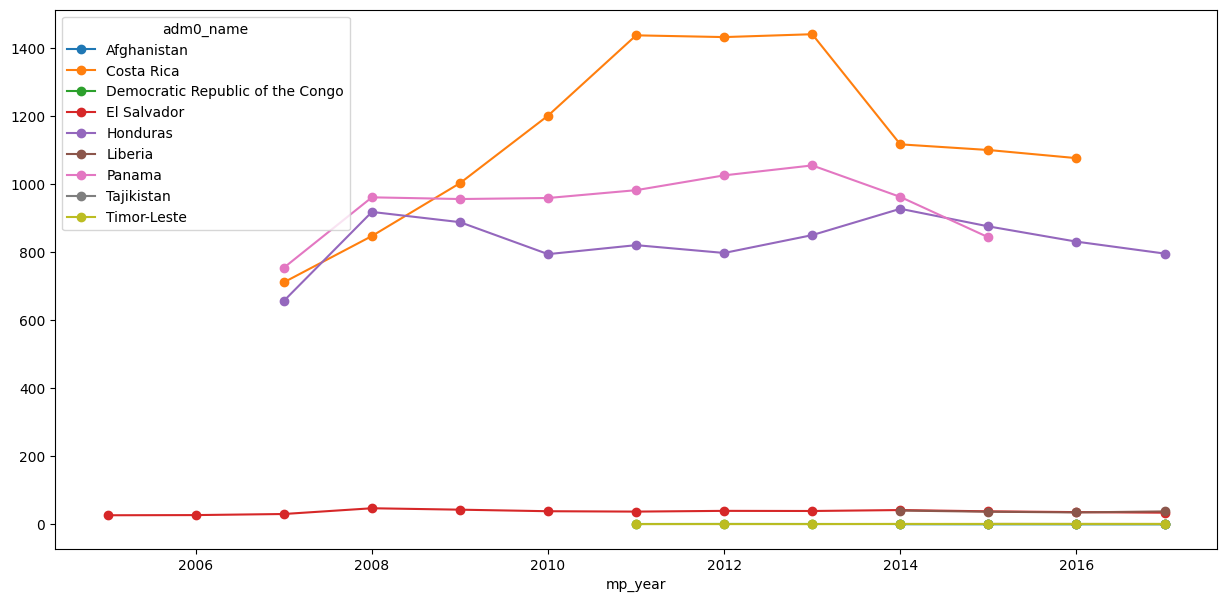

In [128]:
df_stat_multy.plot( figsize=(15,7), marker ='o')

### Correlation Analysis

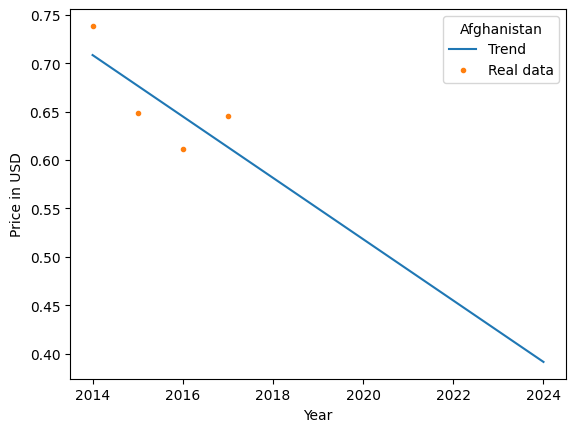

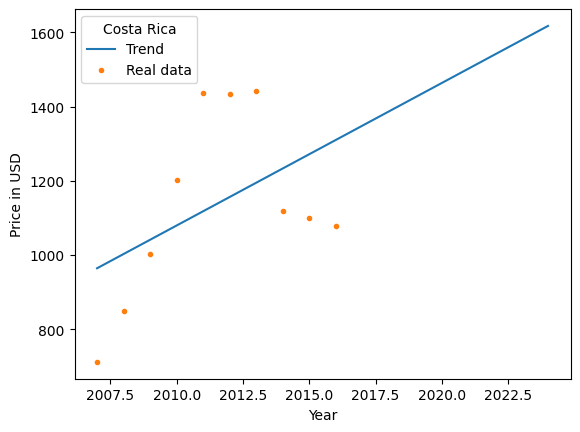

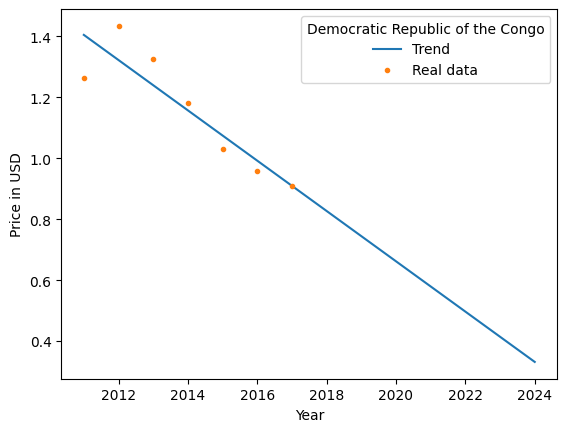

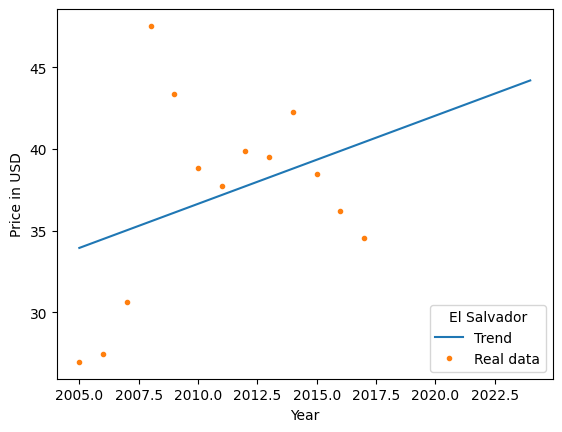

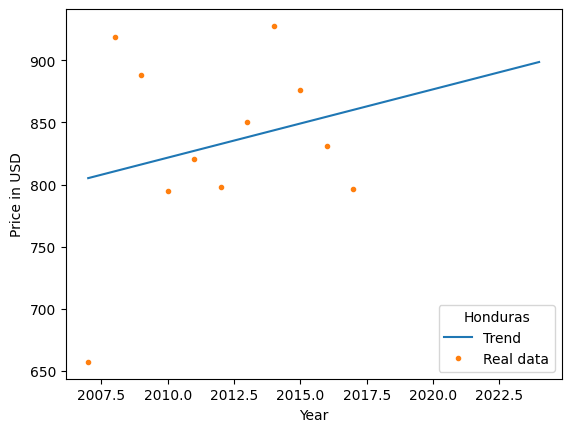

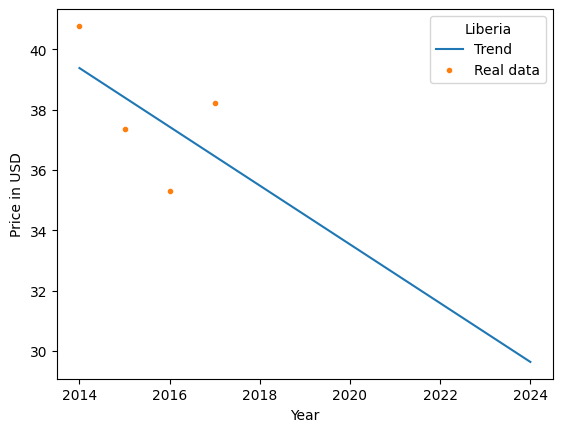

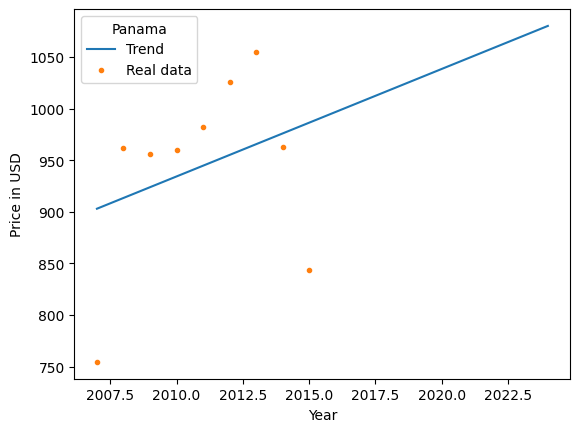

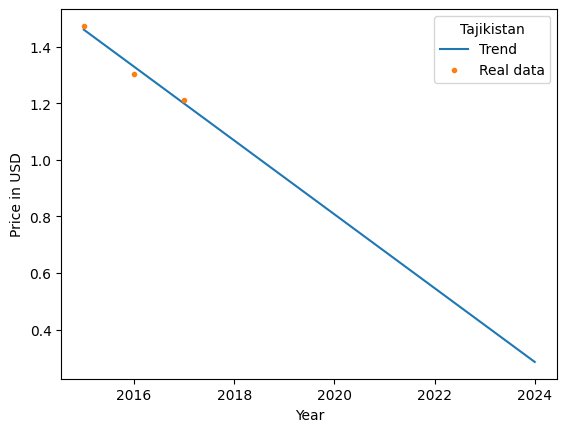

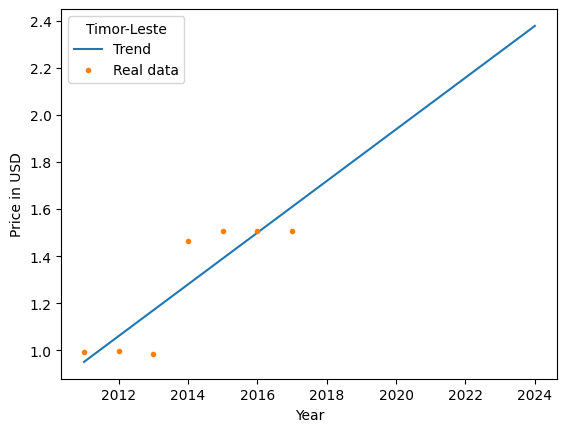

In [136]:
model = LinearRegression()
for c in df_stat_multy.columns:
    y = df_stat_multy[c].dropna()
    x = y.index
    x = np.reshape(x, (-1, 1)) # transform X values
    y = np.reshape(y.values, (-1, 1)) # transform Y values
    model.fit(x, y)
    X_pred= np.append(x, [2022, 2023, 2024])
    X_pred = np.reshape(X_pred, (-1, 1))
        # calculate trend
    trend = model.predict(X_pred)
    plt.figure()
    plt.plot(X_pred, trend, "-", label='Trend')
    plt.plot(x, y, ".", label='Real data')
    plt.xlabel('Year')
    plt.ylabel('Price in USD')
    plt.legend(title=c)
    plt.show()